In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# SelectKBest
from sklearn.datasets import load_iris  ## best for classification (predicting which flower species an observation belongs to.)
from sklearn.feature_selection import SelectKBest,f_classif
X, y = load_iris(return_X_y= True)
print(X.shape)
print(y.shape)
select = SelectKBest(score_func= f_classif, k = 2)
X_new = select.fit_transform(X,y)
X_new.shape

(150, 4)
(150,)


(150, 2)

 ## For regression: r_regression, f_regression, mutual_info_regression

## For classification: chi2, f_classif, mutual_info_classif

In [4]:
# let's try Univariate on breast_cancer_dataset
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns= cancer.feature_names)
df['target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func= f_classif,k = 10)),  
    ## f_classif:ANOVA(analysis of variance) F-value between label/feature for classification tasks.
    ('model', LogisticRegression(max_iter= 5000))
    ])
pipe.fit(cancer.data, cancer.target)
print("the accuracy using f_classif:", pipe.score(cancer.data, cancer.target))

pipe2 = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func= mutual_info_classif, k = 10)),
    ("model", LogisticRegression(max_iter= 5000))
])
pipe2.fit(cancer.data, cancer.target)
print('The score using mutual_info_class:',pipe2.score(cancer.data, cancer.target))

pipe3 = Pipeline([
    ('scaler', MinMaxScaler()),
    ('selector', SelectKBest(score_func= chi2, k = 10)), ##chi2 use non-negative so we Minmaxscaler
    ('models', LogisticRegression(max_iter= 5000))
])
pipe3.fit(cancer.data, cancer.target)
print('the score using chi2:', pipe3.score(cancer.data, cancer.target))

the accuracy using f_classif: 0.9648506151142355
The score using mutual_info_class: 0.9578207381370826
the score using chi2: 0.9437609841827768


In [6]:
## here is how this Pipeline works
# pipe = Pipeline([
#     ('imputer',    SimpleImputer(strategy='median')),      # Step 1: Handle missing values
#     ('scaler',     StandardScaler()),                      # Step 2: Scale
#     ('selector',   SelectKBest(score_func=f_classif, k=15)), # Step 3: Select best features
#     ('pca',        PCA(n_components=0.95)),                # Step 4: Optional dimensionality reduction
#     ('model',      LogisticRegression(max_iter=5000))      # Final Step: Model
# ])

## RFE (Recursive feature elimination) & RFECV ( RFE in cross validation)

run the model and eliminate least imp feature and do it again(recursion)

In [7]:
# RFE(
#     estimator,
#     *,
#     n_features_to_select=None,
#     step=1,
#     verbose=0,
#     importance_getter='auto'
# )
# RFECV(
#     estimator,
#     *,
#     step=1,
#     min_features_to_select=1,
#     cv=None,
#     scoring=None,
#     verbose=0,
#     n_jobs=None,
#     importance_getter='auto'
# )

In [8]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)
pip_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('scale', RFE(estimator = LogisticRegression(max_iter=5000), n_features_to_select= 10)),
    ('model', LogisticRegression(max_iter= 5000))
])
pip_rfe.fit(cancer.data, cancer.target)
print("The score using RFE:", pip_rfe.score(cancer.data, cancer.target))

pip_rfecv = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', RFECV(
        estimator= LogisticRegression(max_iter= 5000),
        step= 1,
        cv = cv,
        scoring = 'accuracy',
        min_features_to_select= 10,
        n_jobs= -1
    )),
    ('model', LogisticRegression(max_iter= 5000))
])
pip_rfecv.fit(cancer.data, cancer.target)
print("The score using RFECV:", pip_rfecv.score(cancer.data, cancer.target))

The score using RFE: 0.9789103690685413
The score using RFECV: 0.9876977152899824


## SelectModel

In [9]:
# SelectFromModel(
#     estimator,
#     *,
#     threshold=None,
#     prefit=False,
#     norm_order=1,
#     max_features=None,
#     importance_getter='auto'
# )

In [10]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
X, y = load_iris(return_X_y=True)
pipe_selectmodel = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(
        # L1 penalty is great for selection because it shrinks unimportant weights to zero
        LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000)
    )),
    ('model', LogisticRegression(max_iter=5000))
])
pipe_selectmodel.fit(X,y)
print("the score using SelectModel:",pipe_selectmodel.score(X, y))
 ## we Randomforestclassifier
 
pipe_tree= Pipeline([
    #  ('scaler', StandardScaler()),     ##for tree classifier we don't use scaler 
     ('selector', SelectFromModel(
         RandomForestClassifier(n_estimators= 300, random_state= 42),
         threshold="median"
     )),
     ('model', LogisticRegression(max_iter= 5000))
     
 ])

pipe_tree.fit(X, y)
print("the score for using Randomforestclassifier:", pipe_tree.score(X,y))
pipe_tree

## SFS on iris data
pipe_sfs_iris = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SequentialFeatureSelector(
        estimator= LogisticRegression(penalty= 'l2', max_iter=5000),
        direction= 'forward',
        cv = cv
    )),
    ('model', LogisticRegression(max_iter= 5000))
])
pipe_sfs_iris.fit(X,y)
print('The score using SFS on iris data using logistic regression:', pipe_sfs_iris.score(X, y))
 ## SFC using Randomforestclassifier
pipe_sfs_rc = Pipeline([
    ('selector', SequentialFeatureSelector(
        estimator= RandomForestClassifier(n_estimators= 300 , random_state= 42),
        direction= 'forward',
        cv = cv,
    )),
    ('model', RandomForestClassifier(n_estimators= 400, random_state=42)) ## use same model again & again leads to overfit.
])
pipe_sfs_rc.fit(X,y)
print("The score in iris data using SFS on RFC:", pipe_sfs_rc.score(X, y))

the score using SelectModel: 0.9733333333333334
the score for using Randomforestclassifier: 0.9666666666666667
The score using SFS on iris data using logistic regression: 0.96
The score in iris data using SFS on RFC: 0.9933333333333333


Training accuracy: 0.9809523809523809
Test accuracy 0.9111111111111111


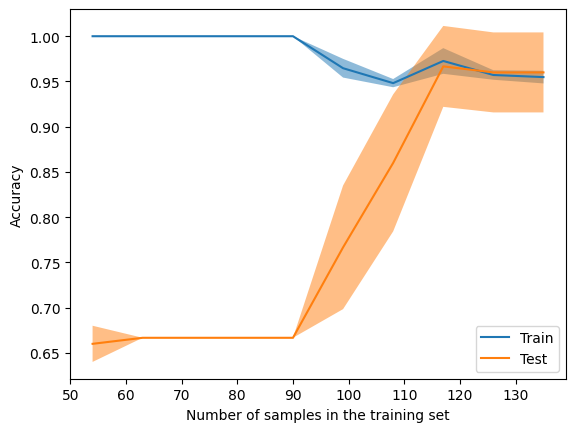

In [ ]:
#Code using Cross validation
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LearningCurveDisplay
X,y = load_iris(return_X_y= True)
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size= 0.3, random_state= 42, stratify= y)
pipe_line = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(
        # L1 penalty is great for selection because it shrinks unimportant weights to zero
        LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=5000),
        max_features=2
    )),
    ('model', LogisticRegression(max_iter=5000))
])
pipe_line.fit(X_train, y_train)
y_train_pred = pipe_line.predict(X_train)
y_test_pred = pipe_line.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Training accuracy:", train_acc)
print("Test accuracy", test_acc)
train_sizes, train_scores, test_scores = learning_curve(
    pipe_line, X, y, cv = 5, n_jobs= -1,
    train_sizes= np.linspace(0.4, 1.0, 10),
    scoring = 'accuracy',
    error_score= 'raise'
)
## we don't even need above code to display this curve.
LearningCurveDisplay.from_estimator(
    pipe_line, X, y,
    train_sizes= np.linspace(0.4, 1.0, 10),
    cv = 10, scoring = 'accuracy',
    n_jobs= -1
)


## Sequential Feature selector

In [ ]:
# sfs = SequentialFeatureSelector(
#     estimator,                    # REQUIRED - The model to use for evaluation
#     n_features_to_select='auto',  # Number of features to keep
#     direction='forward',          # 'forward' or 'backward'
#     scoring=None,                 # Metric to optimize
#     cv=5,                         # Cross-validation folds
#     n_jobs=None,                  # Number of parallel jobs
#     verbose=0,                    # Output verbosity level
#     tol=None                      # Tolerance for early stopping
# )

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
## SFS tries different features and gives the best.
# there is forward and backward
#forward(default) = start with 0 and ad one by one
#backwars = remove one by one
pipe_sfs = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SequentialFeatureSelector(
        LogisticRegression(max_iter= 5000),
        n_features_to_select= 10,
        direction= "forward",
        cv = cv
    )),
    ('model', LogisticRegression(max_iter=5000))
])
pipe_sfs.fit(cancer.data, cancer.target)
print("the score for SFS:", pipe_sfs.score(cancer.data, cancer.target))

the score for SFS: 0.9806678383128296


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty= 'l1', solver= 'liblinear', max_iter= 5000)
model.fit(cancer.data, cancer.target)
model.score(cancer.data, cancer.target)
# use sovler = 'saga' for large datasets
model2 = LogisticRegression(penalty='l1', solver= 'saga', max_iter= 5000)
model2.fit(cancer.data, cancer.target)
model2.score(cancer.data, cancer.target)
# use default l2
model3 = LogisticRegression(penalty= 'l2', max_iter=5000)
model3.fit(cancer.data, cancer.target)
model3.score(cancer.data, cancer.target)


0.9578207381370826